# K-Means on the full EMNIST dataset — CUDA benchmark
## Corrected fit, inference, and carbon methodology

This notebook uses the **entire EMNIST Digits dataset (train + test = 280,000 images)**
with the same from-scratch PyTorch K-Means implementation.

### CPU-vs-GPU reporting

K-Means has two meaningful stages:

1. **Fit/training:** learn the cluster centroids.
2. **Inference/assignment:** assign samples to the already learned centroids.

Therefore both fit time and inference time are reported separately.

The carbon measurement in this notebook is intentionally attached to the
**fit/training workload only**, because the research aim is CPU-based vs
GPU-based training/computation. Inference timing is still reported separately.

### Corrected CodeCarbon design

- full 280,000-image dataset;
- data is moved to the selected device before timing/carbon measurement;
- clean fit and inference timing are measured with CodeCarbon OFF;
- one unmeasured warm-up fit;
- 3 performance repetitions;
- 3 CodeCarbon blocks, each at least 60 seconds;
- `tracking_mode="process"`;
- `measure_power_secs=1`;
- CPU excludes GPUs; GPU explicitly tracks GPU 0;
- energy and CO₂e are normalized per complete K-Means fit.


## 1. Install dependencies
`torch` / `torchvision` are preinstalled on Kaggle. We only add CodeCarbon.

In [1]:
!pip install -q codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 105.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have 

## 2. Config — edit this cell
This replaces the command-line flags from the script version.

In [2]:
# ------------------------- CONFIG ------------------------- #
DEVICE      = "cuda"   # fixed for this notebook
K           = 10
SPLIT       = "digits"            # train + test = 280,000 images
MAX_ITER    = 100
TOL         = 1e-4
BATCH_SIZE  = 16384
SEED        = 42
LIMIT       = None                # None = FULL dataset
USE_CARBON  = True
DATA_ROOT   = "./data"

# Corrected measurement design
WARMUP_RUNS         = 1
PERFORMANCE_REPEATS = 3
CARBON_MEASURE_SECS = 1
ENERGY_BLOCKS       = 3
ENERGY_MIN_DURATION_S = 60.0
ENERGY_COOLDOWN_S   = 5.0
# ---------------------------------------------------------- #


## 3. Imports & device selection

In [3]:
from __future__ import annotations
import time
import numpy as np
import torch


def resolve_device(choice: str) -> torch.device:
    """Turn the DEVICE config into a concrete torch.device."""
    choice = choice.lower()
    if choice == "cpu":
        return torch.device("cpu")
    if choice == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("DEVICE='cuda' but no CUDA GPU is available. "
                               "Set Accelerator=GPU in Kaggle Settings, or use 'auto'/'cpu'.")
        return torch.device("cuda")
    if choice == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    raise ValueError(f"unknown DEVICE '{choice}'. Use cpu, cuda, or auto.")


device = resolve_device(DEVICE)
print(f"Device: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

Device: cuda (Tesla T4)


## 4. Load the full EMNIST dataset (train + test)
Needs **Internet = ON**. `digits` gives 240k train + 40k test = **280,000** images across 10 classes.

In [4]:
def load_emnist(split: str, data_root: str, limit):
    """Load the full EMNIST split as flattened float tensors in [0, 1]."""
    from torchvision import datasets, transforms
    tfm = transforms.Compose([transforms.ToTensor()])

    print(f"Loading EMNIST split='{split}' (downloading if needed) ...")
    train = datasets.EMNIST(root=data_root, split=split, train=True,
                            download=True, transform=tfm)
    test  = datasets.EMNIST(root=data_root, split=split, train=False,
                            download=True, transform=tfm)

    def to_tensors(ds):
        X = ds.data.float().div_(255.0).reshape(len(ds), -1).contiguous()
        y = ds.targets.clone().long()
        return X, y

    Xtr, ytr = to_tensors(train)
    Xte, yte = to_tensors(test)
    X = torch.cat([Xtr, Xte], dim=0)
    y = torch.cat([ytr, yte], dim=0)

    if limit is not None and limit < X.shape[0]:
        g = torch.Generator().manual_seed(0)
        idx = torch.randperm(X.shape[0], generator=g)[:limit]
        X, y = X[idx], y[idx]

    print(f"Full dataset loaded: X={tuple(X.shape)}  "
          f"(train={len(train)} + test={len(test)}), "
          f"{y.unique().numel()} true classes")
    return X, y

## 5. K-means core (batched, CPU/GPU agnostic)
k-means++ init, batched nearest-centroid assignment, vectorized centroid updates, empty-cluster reseeding.

In [5]:
@torch.no_grad()
def _pairwise_assign(X, centroids, batch_size):
    """Assign each row of X to nearest centroid (squared Euclidean), in batches."""
    n = X.shape[0]
    labels = torch.empty(n, dtype=torch.long, device=X.device)
    min_sq = torch.empty(n, dtype=X.dtype, device=X.device)
    c_sq = (centroids * centroids).sum(dim=1)  # (k,)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        xb = X[start:end]
        # ||x - c||^2 = ||x||^2 - 2 x.c + ||c||^2
        d = (xb @ centroids.t()).mul_(-2.0).add_(c_sq)
        d.add_((xb * xb).sum(dim=1, keepdim=True))
        m, lab = d.min(dim=1)
        labels[start:end] = lab
        min_sq[start:end] = m
    return labels, min_sq


@torch.no_grad()
def kmeans_plusplus_init(X, k, batch_size, generator):
    """k-means++ seeding for stable initial centroids."""
    n, d = X.shape
    centroids = torch.empty(k, d, dtype=X.dtype, device=X.device)
    first = torch.randint(0, n, (1,), generator=generator, device=X.device)
    centroids[0] = X[first]
    _, closest_sq = _pairwise_assign(X, centroids[:1], batch_size)
    for i in range(1, k):
        probs = closest_sq.clamp_min(0)
        total = probs.sum()
        if total <= 0:
            nxt = torch.randint(0, n, (1,), generator=generator, device=X.device)
        else:
            nxt = torch.multinomial(probs / total, 1, generator=generator)
        centroids[i] = X[nxt]
        _, new_sq = _pairwise_assign(X, centroids[i:i + 1], batch_size)
        closest_sq = torch.minimum(closest_sq, new_sq)
    return centroids


@torch.no_grad()
def kmeans_fit(X, k, max_iter, tol, batch_size, seed, verbose=True):
    """Lloyd's algorithm. Returns (centroids, labels, inertia)."""
    dev = X.device
    gen = torch.Generator(device=dev).manual_seed(seed)
    centroids = kmeans_plusplus_init(X, k, batch_size, gen)
    d = X.shape[1]
    prev_inertia = None
    for it in range(max_iter):
        labels, min_sq = _pairwise_assign(X, centroids, batch_size)
        inertia = float(min_sq.sum().item())
        new_centroids = torch.zeros(k, d, dtype=X.dtype, device=dev)
        new_centroids.index_add_(0, labels, X)
        counts = torch.bincount(labels, minlength=k).to(X.dtype).clamp_min(1.0)
        new_centroids /= counts.unsqueeze(1)
        empty = torch.bincount(labels, minlength=k) == 0
        if empty.any():
            worst = torch.topk(min_sq, int(empty.sum().item())).indices
            new_centroids[empty] = X[worst]
        shift = float((new_centroids - centroids).pow(2).sum().sqrt().item())
        centroids = new_centroids
        if verbose:
            print(f"  iter {it + 1:3d}/{max_iter}  inertia={inertia:,.1f}  center_shift={shift:.6f}")
        if prev_inertia is not None and abs(prev_inertia - inertia) <= tol * prev_inertia:
            if verbose:
                print(f"  converged (relative inertia change <= tol={tol})")
            break
        prev_inertia = inertia
    labels, min_sq = _pairwise_assign(X, centroids, batch_size)
    inertia = float(min_sq.sum().item())
    return centroids, labels, inertia

## 6. Evaluation vs. ground-truth labels
Clustering accuracy (Hungarian matching), plus NMI and ARI.

In [6]:
def evaluate(labels, y_true, k):
    lab = labels.cpu().numpy()
    yt = y_true.cpu().numpy()
    n_classes = int(yt.max()) + 1
    cost = np.zeros((k, n_classes), dtype=np.int64)
    for c, t in zip(lab, yt):
        cost[c, t] += 1
    acc = None
    try:
        from scipy.optimize import linear_sum_assignment
        row, col = linear_sum_assignment(-cost)
        acc = cost[row, col].sum() / len(yt)
    except Exception as e:
        print(f"  (accuracy skipped: {e})")
    nmi = ari = None
    try:
        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
        nmi = normalized_mutual_info_score(yt, lab)
        ari = adjusted_rand_score(yt, lab)
    except Exception:
        pass
    return acc, nmi, ari

## 7. Run — clean fit + inference timing, then fit-only CodeCarbon blocks

The dataset is moved to the selected device **before** the timer and before
CodeCarbon starts.

- **Fit time:** K-Means centroid learning only.
- **Inference time:** nearest-centroid assignment using already learned centroids.
- **Carbon:** K-Means fit/training only; inference is not included.


In [7]:
import gc
import pandas as pd

# ------------------------------------------------------------
# Data — full dataset
# ------------------------------------------------------------
X_cpu, y_true = load_emnist(
    SPLIT,
    DATA_ROOT,
    LIMIT,
)

# Move data before timing/carbon measurement.
X = X_cpu.to(
    device,
    non_blocking=True,
)

if device.type == "cuda":
    torch.cuda.synchronize()

def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()

# ------------------------------------------------------------
# A. UNMEASURED WARM-UP
# ------------------------------------------------------------
print(
    f"Running {WARMUP_RUNS} unmeasured warm-up fit(s) "
    f"on {device} ..."
)

for warm_idx in range(WARMUP_RUNS):
    warm_centroids, warm_labels, warm_inertia = kmeans_fit(
        X,
        K,
        MAX_ITER,
        TOL,
        BATCH_SIZE,
        SEED + 10000 + warm_idx,
        verbose=False,
    )

    sync_device()

    del warm_centroids
    del warm_labels
    del warm_inertia

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# B. CLEAN PERFORMANCE RUNS — CodeCarbon OFF
# ------------------------------------------------------------
performance_rows = []
performance_objects = []

for repeat_idx in range(PERFORMANCE_REPEATS):
    run_seed = SEED + repeat_idx

    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()

    sync_device()

    # ---- Fit / training ----
    t0 = time.perf_counter()

    centroids, fit_labels, inertia = kmeans_fit(
        X,
        K,
        MAX_ITER,
        TOL,
        BATCH_SIZE,
        run_seed,
        verbose=False,
    )

    sync_device()

    fit_time = (
        time.perf_counter()
        - t0
    )

    # ---- Inference / assignment ----
    t1 = time.perf_counter()

    infer_labels, _ = _pairwise_assign(
        X,
        centroids,
        BATCH_SIZE,
    )

    sync_device()

    infer_time = (
        time.perf_counter()
        - t1
    )

    acc, nmi, ari = evaluate(
        infer_labels,
        y_true,
        K,
    )

    performance_rows.append({
        "repeat": repeat_idx + 1,
        "seed": run_seed,
        "device": str(device),
        "samples": X.shape[0],
        "features": X.shape[1],
        "fit_time_s": fit_time,
        "inference_time_s": infer_time,
        "inference_throughput_samples_s": (
            X.shape[0] / infer_time
            if infer_time > 0
            else np.nan
        ),
        "inertia": inertia,
        "accuracy": acc,
        "nmi": nmi,
        "ari": ari,
    })

    performance_objects.append(
        (centroids, infer_labels, inertia)
    )

    print(
        f"Repeat {repeat_idx + 1}: "
        f"fit={fit_time:.3f}s, "
        f"inference={infer_time:.3f}s, "
        f"NMI={nmi:.4f}, ARI={ari:.4f}"
    )

performance_df = pd.DataFrame(
    performance_rows
)

display(
    performance_df.round(6)
)

# Keep the first run for any later visualization code.
centroids, labels, inertia = performance_objects[0]

# ------------------------------------------------------------
# C. FIT-ONLY LONG-BLOCK CODECARBON
# ------------------------------------------------------------
energy_rows = []

def make_tracker(block):
    if not USE_CARBON:
        return None

    try:
        from codecarbon import EmissionsTracker

        return EmissionsTracker(
            project_name=f"kmeans_emnist_{device.type}_fit_block_{block}",
            measure_power_secs=CARBON_MEASURE_SECS,
            tracking_mode="process",
            gpu_ids=([0] if device.type == "cuda" else []),
            save_to_file=False,
            save_to_api=False,
            log_level="error",
        )

    except Exception as e:
        print(
            f"CodeCarbon unavailable ({e}); "
            f"continuing without carbon tracking."
        )

        return None

if USE_CARBON:
    for block in range(1, ENERGY_BLOCKS + 1):
        gc.collect()

        if device.type == "cuda":
            torch.cuda.empty_cache()

        sync_device()

        tracker = make_tracker(block)

        if tracker is None:
            break

        tracker.start()
        sync_device()

        block_start = time.perf_counter()
        fit_count = 0
        block_seed = SEED + block - 1

        try:
            while True:
                energy_centroids, energy_labels, energy_inertia = kmeans_fit(
                    X,
                    K,
                    MAX_ITER,
                    TOL,
                    BATCH_SIZE,
                    block_seed,
                    verbose=False,
                )

                sync_device()

                fit_count += 1

                del energy_centroids
                del energy_labels
                del energy_inertia

                if (
                    time.perf_counter()
                    - block_start
                ) >= ENERGY_MIN_DURATION_S:
                    break

        finally:
            sync_device()

            duration_s = (
                time.perf_counter()
                - block_start
            )

            emissions_kg = tracker.stop()

        data = getattr(
            tracker,
            "final_emissions_data",
            None,
        )

        def attr(name):
            if data is None:
                return np.nan

            value = getattr(
                data,
                name,
                np.nan,
            )

            return (
                np.nan
                if value is None
                else value
            )

        total_energy_kwh = attr(
            "energy_consumed"
        )

        cpu_energy_kwh = attr(
            "cpu_energy"
        )

        gpu_energy_kwh = attr(
            "gpu_energy"
        )

        ram_energy_kwh = attr(
            "ram_energy"
        )

        row = {
            "block": block,
            "device": str(device),
            "seed": block_seed,
            "fit_count": fit_count,
            "duration_s": duration_s,
            "mean_fit_time_in_block_s": (
                duration_s / fit_count
            ),
            "emissions_block_kg": emissions_kg,
            "emissions_per_fit_kg": (
                emissions_kg / fit_count
            ),
            "emissions_per_fit_g": (
                emissions_kg
                * 1000.0
                / fit_count
            ),
            "energy_block_kwh": total_energy_kwh,
            "energy_per_fit_kwh": (
                total_energy_kwh
                / fit_count
            ),
            "energy_per_fit_wh": (
                total_energy_kwh
                * 1000.0
                / fit_count
            ),
            "cpu_energy_per_fit_kwh": (
                cpu_energy_kwh / fit_count
            ),
            "gpu_energy_per_fit_kwh": (
                gpu_energy_kwh / fit_count
            ),
            "ram_energy_per_fit_kwh": (
                ram_energy_kwh / fit_count
            ),
            "carbon_country": (
                getattr(
                    data,
                    "country_name",
                    None,
                )
                if data is not None
                else None
            ),
        }

        energy_rows.append(
            row
        )

        print(
            f"Energy block {block}: "
            f"{fit_count} fit(s), "
            f"{duration_s:.1f}s, "
            f"{row['emissions_per_fit_g']:.6f} g CO2e/fit, "
            f"{row['energy_per_fit_wh']:.6f} Wh/fit"
        )

        if (
            block < ENERGY_BLOCKS
            and ENERGY_COOLDOWN_S > 0
        ):
            time.sleep(
                ENERGY_COOLDOWN_S
            )

energy_df = pd.DataFrame(
    energy_rows
)

if not energy_df.empty:
    display(
        energy_df.round(8)
    )


Loading EMNIST split='digits' (downloading if needed) ...


100%|██████████| 562M/562M [00:02<00:00, 250MB/s]


Full dataset loaded: X=(280000, 784)  (train=240000 + test=40000), 10 true classes
Running 1 unmeasured warm-up fit(s) on cuda ...
Repeat 1: fit=0.772s, inference=0.019s, NMI=0.4912, ARI=0.3805
Repeat 2: fit=0.638s, inference=0.019s, NMI=0.4609, ARI=0.3551
Repeat 3: fit=0.988s, inference=0.019s, NMI=0.4634, ARI=0.3275


,repeat,seed,device,samples,features,fit_time_s,inference_time_s,inference_throughput_samples_s,inertia,accuracy,nmi,ari
0,1,42,cuda,280000,784,0.772024,0.019451,1.439537e+07,12911969.0,0.578361,0.491203,0.380477
1,2,43,cuda,280000,784,0.638471,0.019416,1.442116e+07,13041300.0,0.537829,0.460886,0.355083
2,3,44,cuda,280000,784,0.987843,0.019452,1.439436e+07,12925750.0,0.489539,0.463408,0.327487


[codecarbon WARNING @ 15:01:47] Multiple instances of codecarbon are allowed to run at the same time.


Energy block 1: 77 fit(s), 60.7s, 0.005052 g CO2e/fit, 0.017696 Wh/fit
Energy block 2: 93 fit(s), 60.1s, 0.004048 g CO2e/fit, 0.014177 Wh/fit
Energy block 3: 57 fit(s), 60.0s, 0.006606 g CO2e/fit, 0.023140 Wh/fit


,block,device,seed,fit_count,duration_s,mean_fit_time_in_block_s,emissions_block_kg,emissions_per_fit_kg,emissions_per_fit_g,energy_block_kwh,energy_per_fit_kwh,energy_per_fit_wh,cpu_energy_per_fit_kwh,gpu_energy_per_fit_kwh,ram_energy_per_fit_kwh,carbon_country
0,1,cuda,42,77,60.693408,0.788226,0.000389,0.000005,0.005052,0.001363,0.000018,0.017696,8.900000e-07,0.000015,0.000002,United States
1,2,cuda,43,93,60.065261,0.645863,0.000376,0.000004,0.004048,0.001318,0.000014,0.014177,7.300000e-07,0.000012,0.000002,United States
2,3,cuda,44,57,60.010244,1.052811,0.000377,0.000007,0.006607,0.001319,0.000023,0.023140,1.180000e-06,0.000019,0.000003,United States


## 8. Results

In [8]:
print("=" * 72)
print("RESULTS — K-MEANS")
print("=" * 72)

print(
    f"Samples clustered       : "
    f"{int(performance_df['samples'].iloc[0]):,}"
)

print(
    f"Feature dim             : "
    f"{int(performance_df['features'].iloc[0])}"
)

print(
    f"k                       : {K}"
)

print(
    f"Device                  : {device}"
)

fit_mean = performance_df[
    "fit_time_s"
].mean()

fit_sd = performance_df[
    "fit_time_s"
].std()

infer_mean = performance_df[
    "inference_time_s"
].mean()

infer_sd = performance_df[
    "inference_time_s"
].std()

throughput_mean = performance_df[
    "inference_throughput_samples_s"
].mean()

print(
    f"Fit/training time       : "
    f"{fit_mean:.3f} ± {fit_sd:.3f} s"
)

print(
    f"Inference time (assign) : "
    f"{infer_mean:.3f} ± {infer_sd:.3f} s"
)

print(
    f"Inference throughput    : "
    f"{throughput_mean:,.0f} samples/s"
)

print(
    f"Final inertia (mean)    : "
    f"{performance_df['inertia'].mean():,.1f}"
)

if performance_df[
    "accuracy"
].notna().any():
    print(
        f"Clustering accuracy     : "
        f"{performance_df['accuracy'].mean():.4f}"
    )

if performance_df[
    "nmi"
].notna().any():
    print(
        f"NMI                     : "
        f"{performance_df['nmi'].mean():.4f}"
    )

if performance_df[
    "ari"
].notna().any():
    print(
        f"ARI                     : "
        f"{performance_df['ari'].mean():.4f}"
    )

if not energy_df.empty:
    carbon_mean = energy_df[
        "emissions_per_fit_g"
    ].mean()

    carbon_sd = energy_df[
        "emissions_per_fit_g"
    ].std()

    energy_mean = energy_df[
        "energy_per_fit_wh"
    ].mean()

    energy_sd = energy_df[
        "energy_per_fit_wh"
    ].std()

    print(
        f"Fit CO2e per fit        : "
        f"{carbon_mean:.6f} ± "
        f"{carbon_sd:.6f} g"
    )

    print(
        f"Fit energy per fit      : "
        f"{energy_mean:.6f} ± "
        f"{energy_sd:.6f} Wh"
    )

    print(
        f"CodeCarbon blocks       : "
        f"{len(energy_df)} "
        f"(min {ENERGY_MIN_DURATION_S:.0f}s each)"
    )

print(
    "Carbon scope            : "
    "K-Means fit/training only; inference excluded"
)

print("=" * 72)

result_summary = pd.DataFrame([{
    "algorithm": "KMeans",
    "device": str(device),
    "samples": int(
        performance_df[
            "samples"
        ].iloc[0]
    ),
    "features": int(
        performance_df[
            "features"
        ].iloc[0]
    ),
    "k": K,
    "fit_time_mean_s": fit_mean,
    "fit_time_std_s": fit_sd,
    "inference_time_mean_s": infer_mean,
    "inference_time_std_s": infer_sd,
    "inference_throughput_mean_samples_s": throughput_mean,
    "accuracy_mean": performance_df["accuracy"].mean(),
    "nmi_mean": performance_df["nmi"].mean(),
    "ari_mean": performance_df["ari"].mean(),
    "co2_per_fit_mean_g": (
        energy_df["emissions_per_fit_g"].mean()
        if not energy_df.empty
        else np.nan
    ),
    "co2_per_fit_std_g": (
        energy_df["emissions_per_fit_g"].std()
        if not energy_df.empty
        else np.nan
    ),
    "energy_per_fit_mean_wh": (
        energy_df["energy_per_fit_wh"].mean()
        if not energy_df.empty
        else np.nan
    ),
    "energy_per_fit_std_wh": (
        energy_df["energy_per_fit_wh"].std()
        if not energy_df.empty
        else np.nan
    ),
}])

display(
    result_summary.round(8)
)


RESULTS — K-MEANS
Samples clustered       : 280,000
Feature dim             : 784
k                       : 10
Device                  : cuda
Fit/training time       : 0.799 ± 0.176 s
Inference time (assign) : 0.019 ± 0.000 s
Inference throughput    : 14,403,632 samples/s
Final inertia (mean)    : 12,959,673.0
Clustering accuracy     : 0.5352
NMI                     : 0.4718
ARI                     : 0.3543
Fit CO2e per fit        : 0.005235 ± 0.001289 g
Fit energy per fit      : 0.018337 ± 0.004516 Wh
CodeCarbon blocks       : 3 (min 60s each)
Carbon scope            : K-Means fit/training only; inference excluded


,algorithm,device,samples,features,k,fit_time_mean_s,fit_time_std_s,inference_time_mean_s,inference_time_std_s,inference_throughput_mean_samples_s,accuracy_mean,nmi_mean,ari_mean,co2_per_fit_mean_g,co2_per_fit_std_g,energy_per_fit_mean_wh,energy_per_fit_std_wh
0,KMeans,cuda,280000,784,10,0.799446,0.176293,0.01944,0.00002,1.440363e+07,0.535243,0.471832,0.354349,0.005235,0.001289,0.018337,0.004516


## 9. Visualize the 10 cluster centroids
Each centroid is the mean image of its cluster, reshaped to 28×28.

> Note: EMNIST images are stored transposed relative to how we usually view them, so we `.T` each centroid for display.

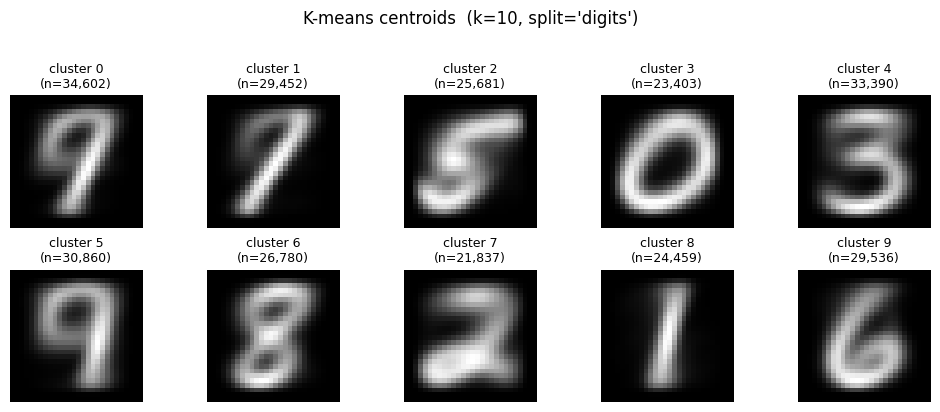

In [9]:
import matplotlib.pyplot as plt

cents = centroids.detach().cpu().numpy().reshape(K, 28, 28)
counts = torch.bincount(labels, minlength=K).cpu().numpy()

cols = 5
rows = (K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
for i, ax in enumerate(axes.ravel()):
    if i < K:
        ax.imshow(cents[i].T, cmap="gray")   # .T to correct EMNIST orientation
        ax.set_title(f"cluster {i}\n(n={counts[i]:,})", fontsize=9)
    ax.axis("off")
plt.suptitle(f"K-means centroids  (k={K}, split='{SPLIT}')", y=1.02)
plt.tight_layout()
plt.show()